<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
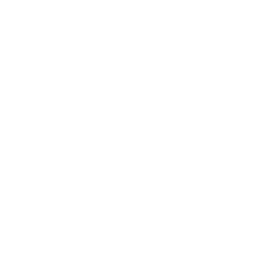
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse des Abstimmungsmusters in Wahlbezirken</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Regierung / Wahlstatistik &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Diese Analyse untersucht, ob die politische Parteizugehörigkeit systematisch zwischen
Wahlbezirkstypen (städtisch, vorstädtisch, ländlich) variiert, in einem simulierten
Wahlkreis-Datensatz von 100 Wahlbezirken. Da mehrere Zellen der Partei-nach-Typ-Tabelle
schwach besetzt sind — die kleinsten Kontingenzzellen enthalten nur ein oder zwei
Wahlbezirke, mit erwarteten Häufigkeiten unter fünf —, ist der allgemeine
Pearson-Chi-Quadrat-Test auf allgemeine Assoziation hier unterversorgt und unzuverlässig.
Wir ergänzen ihn daher mit dem **Cochran-Armitage-Trendtest**, einem fokussierten Test mit
einem Freiheitsgrad, der die natürliche Reihenfolge städtisch-zu-ländlich ausnutzt und eine
schärfere Frage stellt: nimmt die Unterstützung für Partei A entlang dieses Gradienten
monoton ab? Der Trendtest liefert einen exakten p-Wert, was bei kleinen Zellhäufigkeiten die
angemessene Inferenz ist. Der Kontrast zwischen den beiden Tests ist der analytische
Kernpunkt dieses Beispiels: ein allgemeiner Assoziationstest kann ein reales gerichtetes
Muster übersehen, das ein geordneter Trendtest erkennt.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Datensätze auf Wahlbezirksebene, eine Zeile pro Wahlbezirk, mit Bezirkstyp, Landkreis und der Mehrheitspartei | 100 |

Die Laufzeitumgebung läuft im unlizenzierten Modus, der die Ausgabe auf 100 Beobachtungen
begrenzt; die Analyse ist auf diese Stichprobe auf Wahlbezirksebene ausgelegt, sodass die
Kontingenzzellen wirklich klein sind und der exakte Trendtest das naheliegende Werkzeug ist.

---

In [1]:
/* --------------------------------------------------------
   Synthetische Abstimmungsdaten auf Wahlbezirksebene erzeugen
   Kleine Zellhaeufigkeiten in laendlichen Wahlbezirken zeigen
   den Bedarf an exakten Tests
   -------------------------------------------------------- */
DATEN work.precinct_votes;
    AUFRUFEN streaminit(42);
    FELD county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    LÄNGE precinct_type $14 party $12;
    AUSFÜHRUNG precinct_seq = 1 BIS 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Wahlbezirkstyp gewichtet zuweisen */
        type_prob = rand('uniform');
        WENN type_prob < 0.30 DANN precinct_type = 'STÄDTISCH';
        SONST WENN type_prob < 0.65 DANN precinct_type = 'VORSTÄDTISCH';
        SONST precinct_type = 'LÄNDLICH';
        /* Partei mit typabhaengiger Verteilung zuweisen */
        party_prob = rand('uniform');
        WENN precinct_type = 'STÄDTISCH' DANN AUSFÜHRUNG;
            WENN party_prob < 0.55 DANN party = 'PARTEI_A';
            SONST WENN party_prob < 0.80 DANN party = 'PARTEI_B';
            SONST WENN party_prob < 0.92 DANN party = 'PARTEI_C';
            SONST party = 'UNABHÄNGIG';
        ENDE;
        SONST WENN precinct_type = 'VORSTÄDTISCH' DANN AUSFÜHRUNG;
            WENN party_prob < 0.40 DANN party = 'PARTEI_A';
            SONST WENN party_prob < 0.75 DANN party = 'PARTEI_B';
            SONST WENN party_prob < 0.88 DANN party = 'PARTEI_C';
            SONST party = 'UNABHÄNGIG';
        ENDE;
        SONST AUSFÜHRUNG; /* LAENDLICH - kleinere Zellen fuer Minderheitsparteien */
            WENN party_prob < 0.25 DANN party = 'PARTEI_A';
            SONST WENN party_prob < 0.70 DANN party = 'PARTEI_B';
            SONST WENN party_prob < 0.85 DANN party = 'PARTEI_C';
            SONST party = 'UNABHÄNGIG';
        ENDE;
        /* Stimmenzahl variiert nach Wahlbezirkstyp */
        WENN precinct_type = 'STÄDTISCH' DANN
            vote_count = int(rand('normal', 120, 40));
        SONST WENN precinct_type = 'VORSTÄDTISCH' DANN
            vote_count = int(rand('normal', 80, 25));
        SONST
            vote_count = int(rand('normal', 25, 12));
        WENN vote_count < 1 DANN vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        AUSGABE;
    ENDE;
    ENTFERNEN precinct_seq county_idx type_prob party_prob;
AUSFÜHREN;


NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

                                                   The FREQ Procedure

Wahlbezirkstyp    Frequency    Percent
---------------------------------------
LÄNDLICH                 34     34.00
STÄDTISCH                29     29.00
VORSTÄDTISCH             37     37.00

Partei         Frequency    Percent
------------------------------------
PARTEI_A              45     45.00
PARTEI_B              34     34.00
PARTEI_C              12     12.00
UNABHÄNGIG             9      9.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


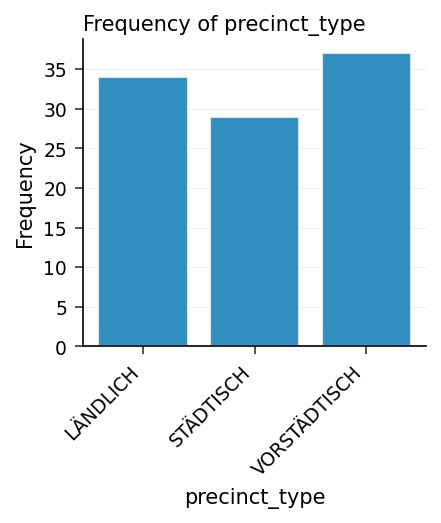

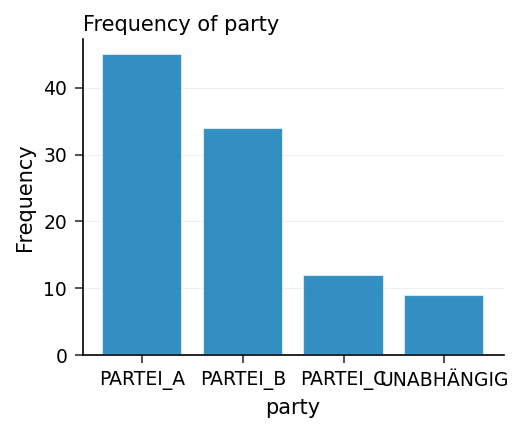

In [2]:
/* --------------------------------------------------------
   Basisverteilung von Wahlbezirkstyp und Partei
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    BEZEICHNUNG precinct_type = "Wahlbezirkstyp" party = "Partei";
AUSFÜHREN;

---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


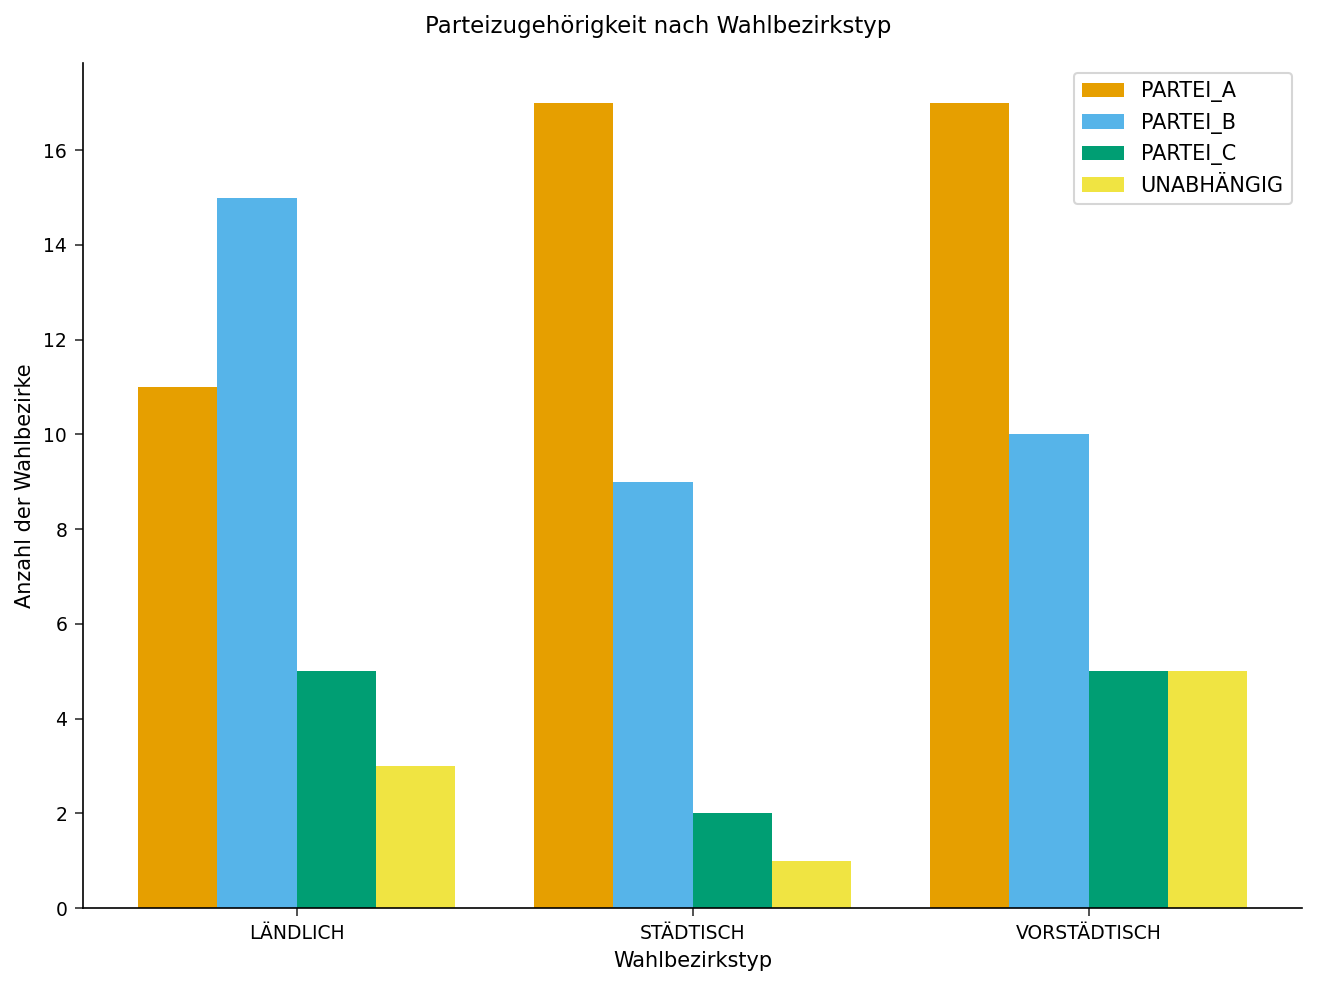

In [3]:
/* --------------------------------------------------------
   Parteizugehoerigkeit nach Wahlbezirkstyp (Wahlbezirksanzahl)
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=HÄUFIGKEITEN;
    XAXIS BEZEICHNUNG="Wahlbezirkstyp";
    YAXIS BEZEICHNUNG="Anzahl der Wahlbezirke";
    TITEL "Parteizugehörigkeit nach Wahlbezirkstyp";
AUSFÜHREN;

---

                          Wahlbezirkstyp nach Partei: Kreuztabelle mit erwarteten Häufigkeiten                          

                                                   The FREQ Procedure

Table of Wahlbezirkstyp by Partei

Wahlbezirkstyp |   PARTEI_A |   PARTEI_B |   PARTEI_C | UNABHÄNGIG |       Total
---------------+------------+------------+------------+------------+------------
LÄNDLICH       |         11 |         15 |          5 |          3 |          34
               |      11.00 |      15.00 |       5.00 |       3.00 |       34.00
               |      15.30 |      11.56 |       4.08 |       3.06 |            
               |      32.35 |      44.12 |      14.71 |       8.82 |      100.00
               |      24.44 |      44.12 |      41.67 |      33.33 |       34.00
---------------+------------+------------+------------+------------+------------
STÄDTISCH      |         17 |          9 |          2 |          1 |          29
               |      17.00 |       9.00 | 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


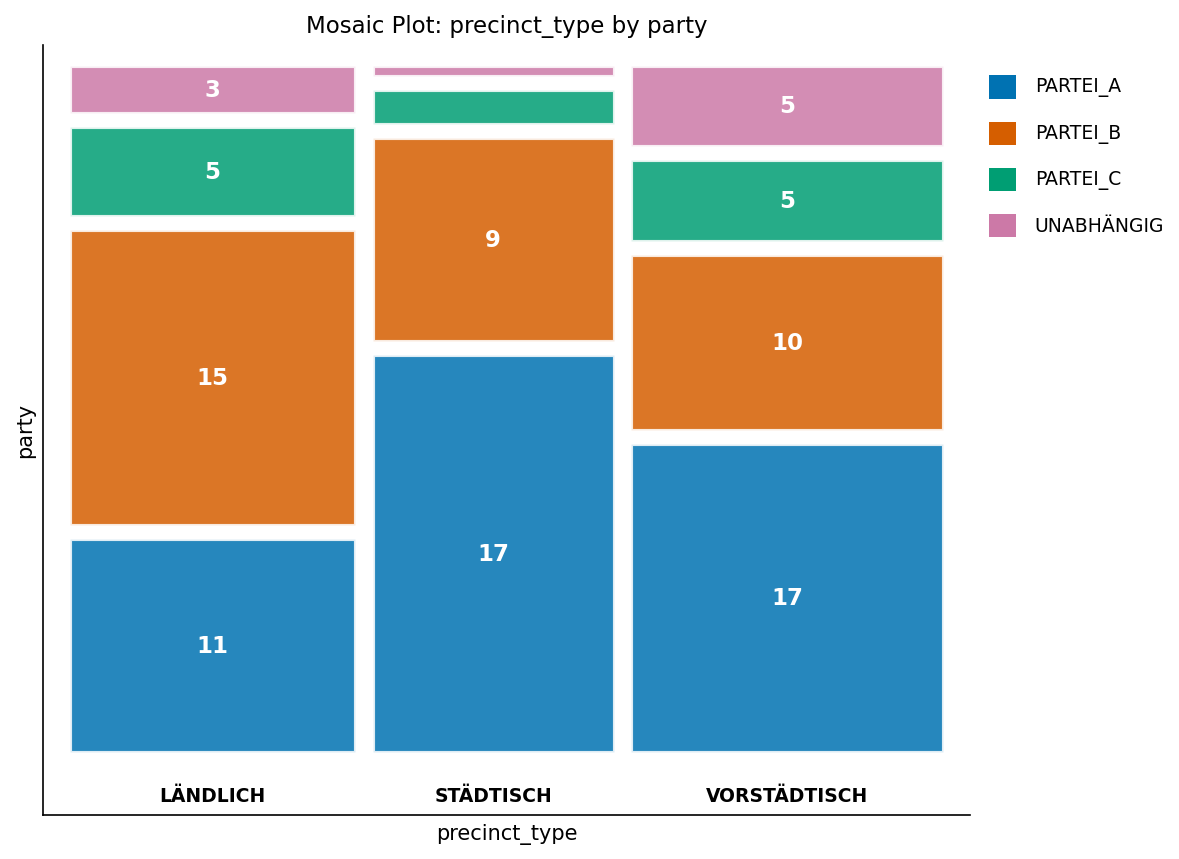

In [4]:
/* --------------------------------------------------------
   Kreuztabelle Wahlbezirkstyp x Partei.
   EXPECTED-Haeufigkeiten anfordern, damit die schwach besetzten
   Zellen sichtbar werden, dazu der asymptotische Pearson-
   Chi-Quadrat-Test auf allgemeine Assoziation. Man beachte die
   kleinen erwarteten Haeufigkeiten in den Spalten UNABHAENGIG
   und PARTEI_C -- der Hinweis, dass ein geordneter, exakter
   Trendtest das bessere Inferenzwerkzeug ist.
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    BEZEICHNUNG precinct_type = "Wahlbezirkstyp" party = "Partei";
    TITEL "Wahlbezirkstyp nach Partei: Kreuztabelle mit erwarteten Häufigkeiten";
AUSFÜHREN;

                Cochran-Armitage-Trendtest: Unterstützung für Partei A entlang des Wahlbezirksgradienten                

                                                   The FREQ Procedure

Table of Städtisch-ländlich-Gradient by Partei A (Unterstützung)

Städtisch-ländlich-Gradient   |         0 |         1 |      Total
------------------------------+-----------+-----------+-----------
1                             |        12 |        17 |         29
                              |     12.00 |     17.00 |      29.00
                              |     41.38 |     58.62 |     100.00
                              |     21.82 |     37.78 |      29.00
------------------------------+-----------+-----------+-----------
2                             |        20 |        17 |         37
                              |     20.00 |     17.00 |      37.00
                              |     54.05 |     45.95 |     100.00
                              |     36.36 |     37.78 |      37.00
----


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


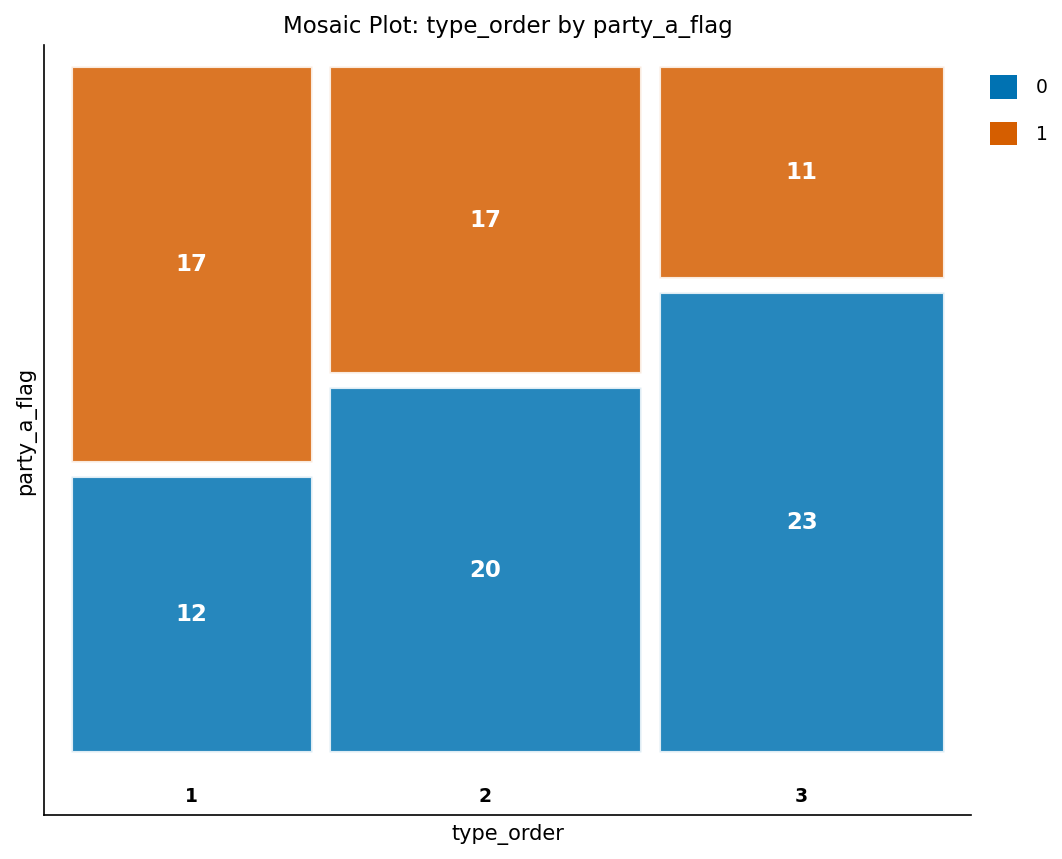

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage-Trendtest. Wahlbezirkstyp in einen ordinalen
   Score umkodieren (1=staedtisch, 2=vorstaedtisch, 3=laendlich)
   und testen, ob die Unterstuetzung fuer Partei A einen
   monotonen Trend entlang des Gradienten zeigt. EXACT TREND
   fordert den exakten p-Wert an, angemessen angesichts der
   kleinen Zellhaeufigkeiten.
   -------------------------------------------------------- */
DATEN work.precinct_ordinal;
    FESTLEGEN work.precinct_votes;
    /* Ordinale Kodierung: 1=staedtisch, 2=vorstaedtisch, 3=laendlich */
    WENN precinct_type = 'STÄDTISCH' DANN type_order = 1;
    SONST WENN precinct_type = 'VORSTÄDTISCH' DANN type_order = 2;
    SONST type_order = 3;
    /* Binaeres Ergebnis: Partei A gegen alle anderen Zugehoerigkeiten */
    party_a_flag = (party = 'PARTEI_A');
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    BEZEICHNUNG type_order = "Städtisch-ländlich-Gradient" party_a_flag = "Partei A (Unterstützung)";
    TITEL "Cochran-Armitage-Trendtest: Unterstützung für Partei A entlang des Wahlbezirksgradienten";
AUSFÜHREN;

                                Verteilung des Wahlbezirkstyps innerhalb der Landkreise                                 

                                                   The FREQ Procedure

Table of Landkreis by Wahlbezirkstyp

Landkreis |     LÄNDLICH |    STÄDTISCH | VORSTÄDTISCH |         Total
----------+--------------+--------------+--------------+--------------
ADAMS     |            5 |            4 |           10 |            19
          |         5.00 |         4.00 |        10.00 |         19.00
          |        26.32 |        21.05 |        52.63 |        100.00
          |        14.71 |        13.79 |        27.03 |         19.00
----------+--------------+--------------+--------------+--------------
HAMILTON  |            7 |            7 |            7 |            21
          |         7.00 |         7.00 |         7.00 |         21.00
          |        33.33 |        33.33 |        33.33 |        100.00
          |        20.59 |        24.14 |        18.92 |   


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


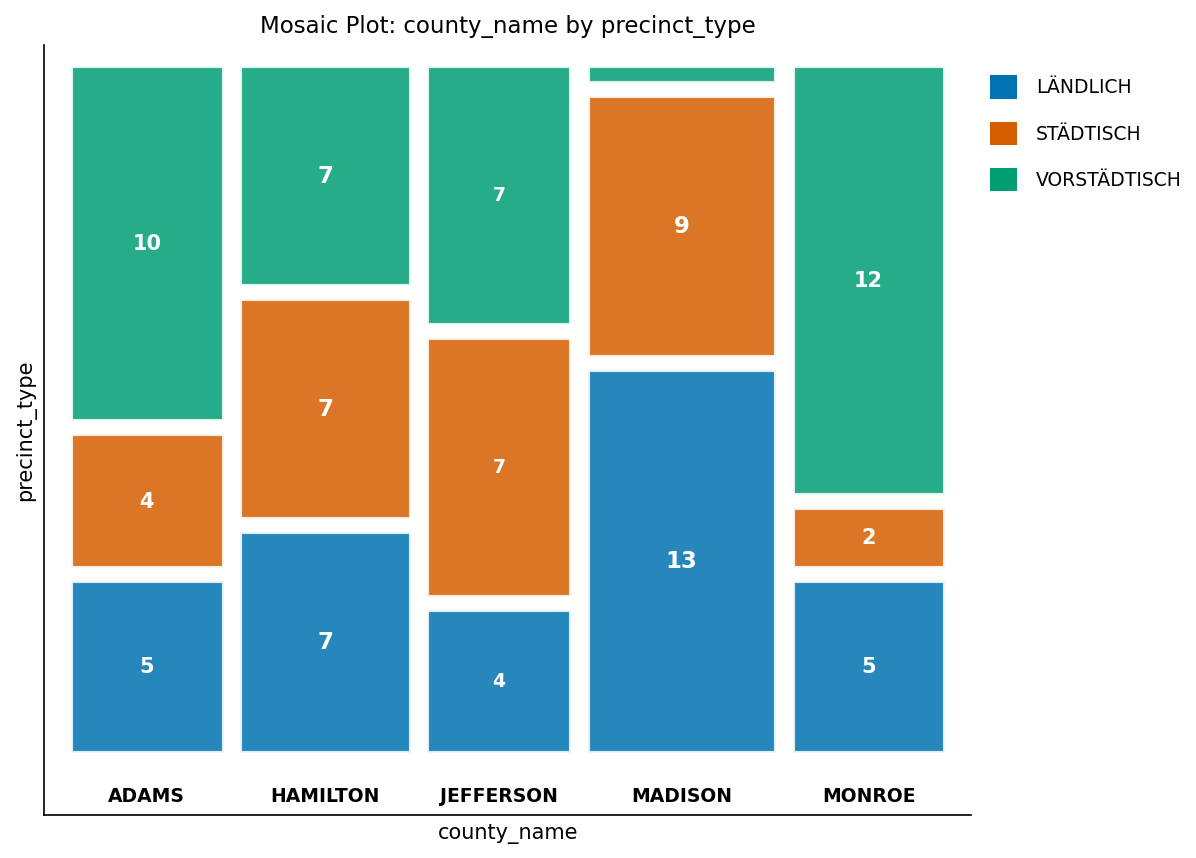

In [6]:
/* --------------------------------------------------------
   Ansicht auf Landkreisebene: wie die staedtisch/vorstaedtisch/
   laendlich-Mischung sich ueber die fuenf Landkreise unter-
   scheidet. Dies stellt das Trendergebnis in den Kontext -- der
   Wahlbezirksgradient ist in jedem Landkreis vorhanden, seine
   Zusammensetzung unterscheidet sich jedoch.
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    BEZEICHNUNG county_name = "Landkreis" precinct_type = "Wahlbezirkstyp";
    TITEL "Verteilung des Wahlbezirkstyps innerhalb der Landkreise";
AUSFÜHREN;

---

### Interpretation

Über die 100 Wahlbezirke hinweg hält Partei A insgesamt die Mehrheit (45 Wahlbezirke),
gefolgt von Partei B (34), Partei C (12) und Unabhängigen (9). Die Kreuztabelle zeigt, dass
der Anteil von Partei A einem klaren Gradienten von städtisch zu ländlich folgt: sie
entfällt auf 58,6 % der städtischen Wahlbezirke, 46,0 % der vorstädtischen Wahlbezirke und
32,4 % der ländlichen Wahlbezirke, während sich Partei B in die entgegengesetzte Richtung
bewegt und von 31,0 % städtisch auf 44,1 % ländlich steigt.

Der allgemeine Pearson-Chi-Quadrat-Test auf allgemeine Assoziation ist **nicht**
statistisch signifikant (Chi-Quadrat = 6,78, 6 Freiheitsgrade, p = 0,3418; Cramérs V =
0,18). Dieses Ergebnis ist zudem fragil: die Anzeige der erwarteten Häufigkeiten zeigt
mehrere Zellen unter fünf — zum Beispiel hat die Spalte der Unabhängigen erwartete
Häufigkeiten von 3,06, 3,33 und 2,61, und städtische Unabhängige zählen nur einen
Wahlbezirk —, sodass die Chi-Quadrat-Approximation für große Stichproben hier unzuverlässig
ist.

Der Cochran-Armitage-Trendtest schärft die Frage, indem er die ordinale Bewertung
städtisch-vorstädtisch-ländlich nutzt. Er erkennt den monotonen Rückgang der Unterstützung
für Partei A, den der allgemeine Test übersieht: Trend-Chi-Quadrat = 4,38 mit einem
asymptotischen Pr > ChiSq = 0,0363 und einem **exakten Pr >= |Z| = 0,0431**, signifikant
auf dem 0,05-Niveau. Das ist der analytische Gewinn — ein fokussierter, exakter Test mit
einem Freiheitsgrad findet ein reales gerichtetes Signal, das der allgemeine Test mit 6
Freiheitsgraden, geschwächt durch schwach besetzte Zellen, nicht findet.

Die Ansicht auf Landkreisebene bestätigt, dass die Aufteilung städtisch/vorstädtisch/
ländlich in allen fünf Landkreisen vorhanden ist, wenngleich die Mischung unterschiedlich
ist: Madison ist am stärksten ländlich geprägt (13 von 23 Wahlbezirken ländlich), während
Monroe am stärksten vorstädtisch ist (12 von 19). Für die Bewertung der Auswirkungen einer
Neuabgrenzung ist die Erkenntnis, dass Grenzänderungen, die Wahlbezirke entlang der
städtisch-ländlichen Achse verschieben, die parteipolitische Zusammensetzung messbar
verändern würden, und dass dieser geografische Trend am besten durch den exakten Trendtest
belegt wird und nicht durch den allgemeinen Chi-Quadrat-Test.

---

                                Verteilung des Wahlbezirkstyps innerhalb der Landkreise                                 

                                                   The FREQ Procedure

Table of precinct_type by party

precinct_type |   PARTEI_A |   PARTEI_B |   PARTEI_C | UNABHÄNGIG |       Total
--------------+------------+------------+------------+------------+------------
LÄNDLICH      |         11 |         15 |          5 |          3 |          34
              |      11.00 |      15.00 |       5.00 |       3.00 |       34.00
              |      32.35 |      44.12 |      14.71 |       8.82 |      100.00
              |      24.44 |      44.12 |      41.67 |      33.33 |       34.00
--------------+------------+------------+------------+------------+------------
STÄDTISCH     |         17 |          9 |          2 |          1 |          29
              |      17.00 |       9.00 |       2.00 |       1.00 |       29.00
              |      58.62 |      31.03 |       6.90 |


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


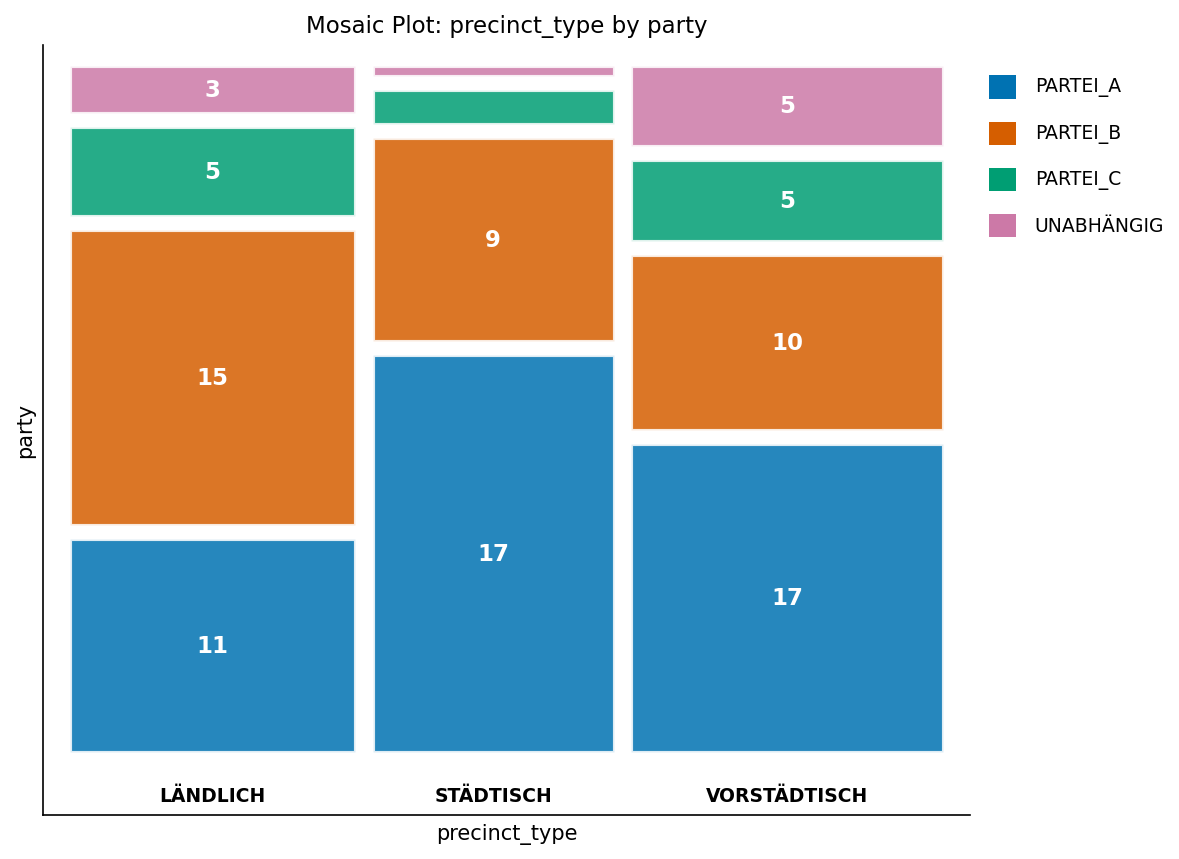

In [7]:
/* --------------------------------------------------------
   Zusammenfassung Wahlbezirkstyp x Partei fuer die
   nachgelagerte Bewertung der Neuabgrenzung exportieren
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>